In [6]:
# Data Splitting Script for Dental Segmentation
import os
import shutil
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def split_dataset(source_dir, output_dir, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1, random_seed=42):
    """
    Split the dataset into training, validation, and test sets.
    
    Args:
        source_dir: Path to the directory containing all images and masks
        output_dir: Directory where the split datasets will be saved
        train_ratio: Ratio of training data
        val_ratio: Ratio of validation data
        test_ratio: Ratio of test data
        random_seed: Random seed for reproducibility
    """
    # Verify ratios add up to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-5, "Ratios must sum to 1"
    
    # Create output directories
    os.makedirs(output_dir, exist_ok=True)
    train_dir = os.path.join(output_dir, 'train')
    val_dir = os.path.join(output_dir, 'val')
    test_dir = os.path.join(output_dir, 'test')
    
    # Create subdirectories for images and masks in each split
    for split_dir in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(split_dir, 'images'), exist_ok=True)
        os.makedirs(os.path.join(split_dir, 'masks'), exist_ok=True)
    
    # Get list of all files in source directory
    all_files = os.listdir(source_dir)
    
    # Identify image files (assuming all non-mask images are training images)
    # This will depend on your naming convention
    image_files = [f for f in all_files if not f.endswith('_mask.png') and (f.endswith('.png') or f.endswith('.jpg') or f.endswith('.jpeg'))]
    
    # Read the class information if available
    classes_csv = os.path.join(source_dir, '_classes.csv')
    if os.path.exists(classes_csv):
        try:
            classes_df = pd.read_csv(classes_csv)
            print(f"Loaded classes CSV with {len(classes_df)} entries")
            # Copy the CSV to the output directory
            shutil.copy(classes_csv, output_dir)
        except Exception as e:
            print(f"Warning: Could not load classes CSV: {e}")
    else:
        print("Warning: Classes CSV file not found")
    
    # Split the filenames
    train_files, temp_files = train_test_split(
        image_files, test_size=(val_ratio + test_ratio), random_state=random_seed)
    
    # Further split temp_files into validation and test
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
    val_files, test_files = train_test_split(
        temp_files, test_size=(1 - val_ratio_adjusted), random_state=random_seed)
    
    print(f"Total images: {len(image_files)}")
    print(f"Training: {len(train_files)} images ({train_ratio*100:.1f}%)")
    print(f"Validation: {len(val_files)} images ({val_ratio*100:.1f}%)")
    print(f"Testing: {len(test_files)} images ({test_ratio*100:.1f}%)")
    
    # Function to copy files to respective directories
    def copy_files(files, destination_subdir):
        for filename in files:
            # Image file
            src_path = os.path.join(source_dir, filename)
            dst_path = os.path.join(destination_subdir, 'images', filename)
            shutil.copy(src_path, dst_path)
            
            # Corresponding mask file (adjust based on your naming convention)
            # Assuming masks have the same name but with _mask.png suffix
            mask_filename = os.path.splitext(filename)[0] + '_mask.png'
            src_mask_path = os.path.join(source_dir, mask_filename)
            
            if os.path.exists(src_mask_path):
                dst_mask_path = os.path.join(destination_subdir, 'masks', mask_filename)
                shutil.copy(src_mask_path, dst_mask_path)
            else:
                print(f"Warning: Mask not found for {filename}")
    
    # Copy files to respective directories
    copy_files(train_files, train_dir)
    copy_files(val_files, val_dir)
    copy_files(test_files, test_dir)
    
    print("Dataset split complete!")
    return train_dir, val_dir, test_dir

if __name__ == "__main__":
    # Example usage
    source_directory = "../data"
    output_directory = "../data/split_dataset"
    
    train_dir, val_dir, test_dir = split_dataset(
        source_directory, 
        output_directory,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1
    )
    
    print(f"Training data: {train_dir}")
    print(f"Validation data: {val_dir}")
    print(f"Test data: {test_dir}")

Loaded classes CSV with 3 entries
Total images: 1573
Training: 1258 images (80.0%)
Validation: 157 images (10.0%)
Testing: 158 images (10.0%)
Dataset split complete!
Training data: ../data/split_dataset\train
Validation data: ../data/split_dataset\val
Test data: ../data/split_dataset\test


In [7]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, concatenate, Conv2DTranspose
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
N_CLASSES = 3  # Background, ABC, CEJ
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4

# Force CPU usage
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
tf.config.threading.set_intra_op_parallelism_threads(4)
tf.config.threading.set_inter_op_parallelism_threads(2)

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Only normalization, no augmentation
datagen = ImageDataGenerator(rescale=1./255)

# Create generators for training, validation, and testing datasets
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 2516 images belonging to 2 classes.
Found 314 images belonging to 2 classes.
Found 316 images belonging to 2 classes.


In [9]:
#model definition
def build_unet_light(input_shape, n_classes):
    inputs = Input(input_shape)
    
    # Encoder
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(0.1)(p1)

    c2 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p1)
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(0.2)(p2)

    c3 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p2)
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(0.3)(p3)

    # Bridge
    c4 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p3)
    c4 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c4)
    c4 = Dropout(0.4)(c4)

    # Decoder
    u5 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u5)
    c5 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c5)
    c5 = Dropout(0.3)(c5)

    u6 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u6)
    c6 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c6)
    c6 = Dropout(0.2)(c6)

    u7 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u7)
    c7 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c7)
    c7 = Dropout(0.1)(c7)

    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c7)

    return Model(inputs=[inputs], outputs=[outputs])


In [10]:
#helper functions
def create_color_mask(mask):
    if mask.ndim > 2:
        mask = np.argmax(mask, axis=-1)
    rgb_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    rgb_mask[mask == 0] = [0, 0, 0]     # Background
    rgb_mask[mask == 1] = [0, 255, 0]   # ABC
    rgb_mask[mask == 2] = [255, 0, 0]   # CEJ
    return rgb_mask

In [11]:
#load dataset
def load_dataset(data_dir):
    images_path = os.path.join(data_dir, 'images')
    masks_path = os.path.join(data_dir, 'masks')
    
    images, masks, filenames = [], [], []
    image_files = [f for f in os.listdir(images_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in image_files:
        mask_file = os.path.splitext(img_file)[0] + '_mask.png'
        img_path = os.path.join(images_path, img_file)
        mask_path = os.path.join(masks_path, mask_file)
        
        if not os.path.exists(mask_path):
            continue
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0

        mask = cv2.imread(mask_path, 0)
        if mask is None: continue
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)

        images.append(img)
        masks.append(mask)
        filenames.append(img_file)

    X = np.array(images)
    y = to_categorical(np.array(masks), N_CLASSES)
    
    return X, y, filenames

In [12]:
#visualization
def visualize_masks(img, true_mask, pred_mask=None, title="Segmentation Results"):
    plt.figure(figsize=(12, 4))
    plt.subplot(131); plt.imshow(img); plt.title("Original"); plt.axis("off")
    plt.subplot(132); plt.imshow(np.argmax(true_mask, axis=-1), cmap='viridis'); plt.title("True"); plt.axis("off")
    if pred_mask is not None:
        plt.subplot(133); plt.imshow(np.argmax(pred_mask, axis=-1), cmap='viridis'); plt.title("Predicted"); plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def visualize_samples(X, y, num_samples=3):
    for i in range(min(num_samples, len(X))):
        visualize_masks(X[i], y[i], title=f"Sample {i+1}")


In [13]:
#validation testing
def test_on_validation(model, X_val, y_val, num_samples=5):
    predictions = model.predict(X_val[:num_samples])
    for i in range(num_samples):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(X_val[i]); axes[0].set_title('Original'); axes[0].axis('off')
        axes[1].imshow(create_color_mask(y_val[i])); axes[1].set_title('Ground Truth'); axes[1].axis('off')
        axes[2].imshow(create_color_mask(predictions[i])); axes[2].set_title('Prediction'); axes[2].axis('off')
        plt.tight_layout()
        plt.show()


In [14]:
#prediction of new image
def predict_on_image(model, image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img.shape[:2]
    
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
    prediction = model.predict(np.expand_dims(img_resized, axis=0))[0]
    
    pred_mask = np.argmax(prediction, axis=-1)
    color_mask = create_color_mask(pred_mask)
    color_mask_resized = cv2.resize(color_mask, (original_w, original_h), interpolation=cv2.INTER_NEAREST)
    
    blended = cv2.addWeighted(img, 0.5, color_mask_resized, 0.5, 0)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(131); plt.imshow(img); plt.title('Original'); plt.axis('off')
    plt.subplot(132); plt.imshow(color_mask); plt.title('Mask'); plt.axis('off')
    plt.subplot(133); plt.imshow(blended); plt.title('Blended'); plt.axis('off')
    plt.tight_layout(); plt.show()

    return pred_mask, color_mask


In [15]:
#train model
def train_model(train_dir, val_dir, test_dir):
    X_train, y_train, _ = load_dataset(train_dir)
    X_val, y_val, _ = load_dataset(val_dir)
    X_test, y_test, _ = load_dataset(test_dir)
    
    visualize_samples(X_train, y_train, num_samples=2)
    
    model = build_unet_light((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), N_CLASSES)
    model.compile(optimizer=Adam(LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])

    callbacks = [
        ModelCheckpoint('best_unet_model.keras', save_best_only=True, monitor='val_loss'),
        EarlyStopping(patience=10, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.2, patience=5, min_lr=1e-6)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks
    )

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title('Loss'); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title('Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()
    
    test_on_validation(model, X_val, y_val)
    
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
    
    model.save('dental_segmentation_model.keras')
    return model, history


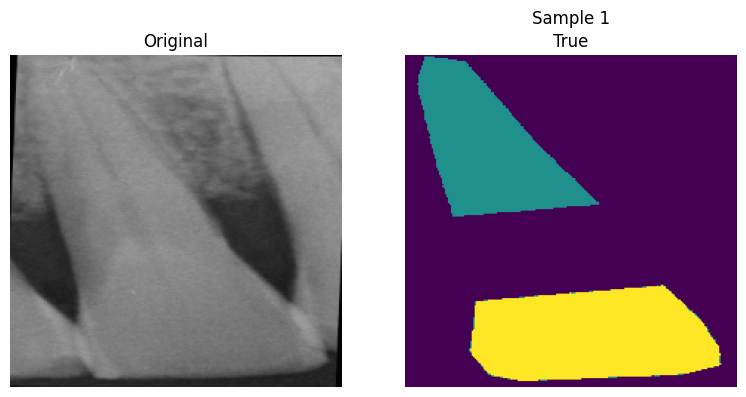

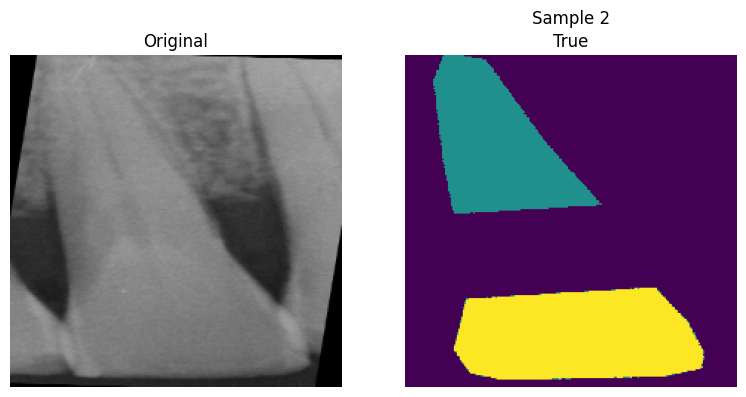

Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 856s 5s/step - accuracy: 0.5482 - loss: 0.9936 - val_accuracy: 0.5396 - val_loss: 0.9255 - learning_rate: 1.0000e-04
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 559s 4s/step - accuracy: 0.6197 - loss: 0.8231 - val_accuracy: 0.6127 - val_loss: 0.8043 - learning_rate: 1.0000e-04
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 526s 3s/step - accuracy: 0.6723 - loss: 0.7470 - val_accuracy: 0.6400 - val_loss: 0.7636 - learning_rate: 1.0000e-04
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 931s 6s/step - accuracy: 0.7034 - loss: 0.6886 - val_accuracy: 0.6754 - val_loss: 0.7204 - learning_rate: 1.0000e-04
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 972s 6s/step - accuracy: 0.7143 - loss: 0.6675 - val_accuracy: 0.6867 - val_loss: 0.7154 - learning_rate: 1.0000e-04
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 1099s 7s/step - accuracy: 0.7277 - loss: 0.6415 - val_accuracy: 0.7191 - val_loss: 0.6373 - learning_rate: 1.0000e-04
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 1151s 7s/step - a

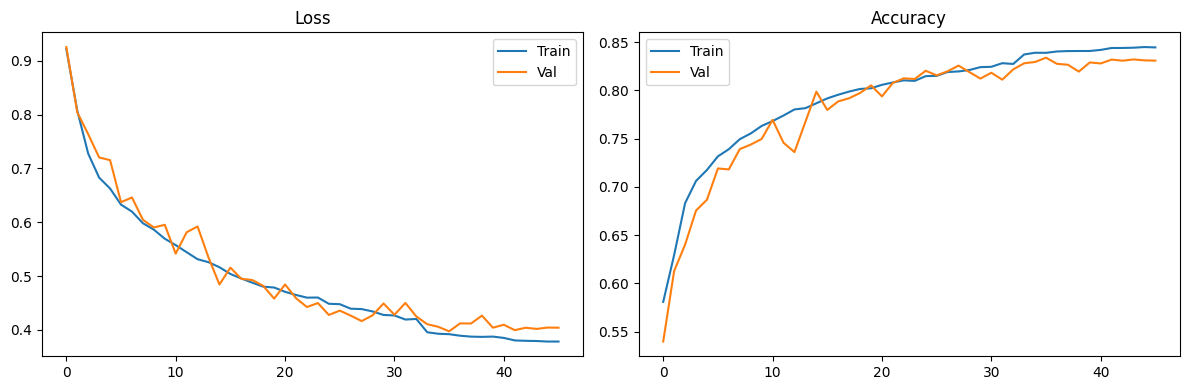

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


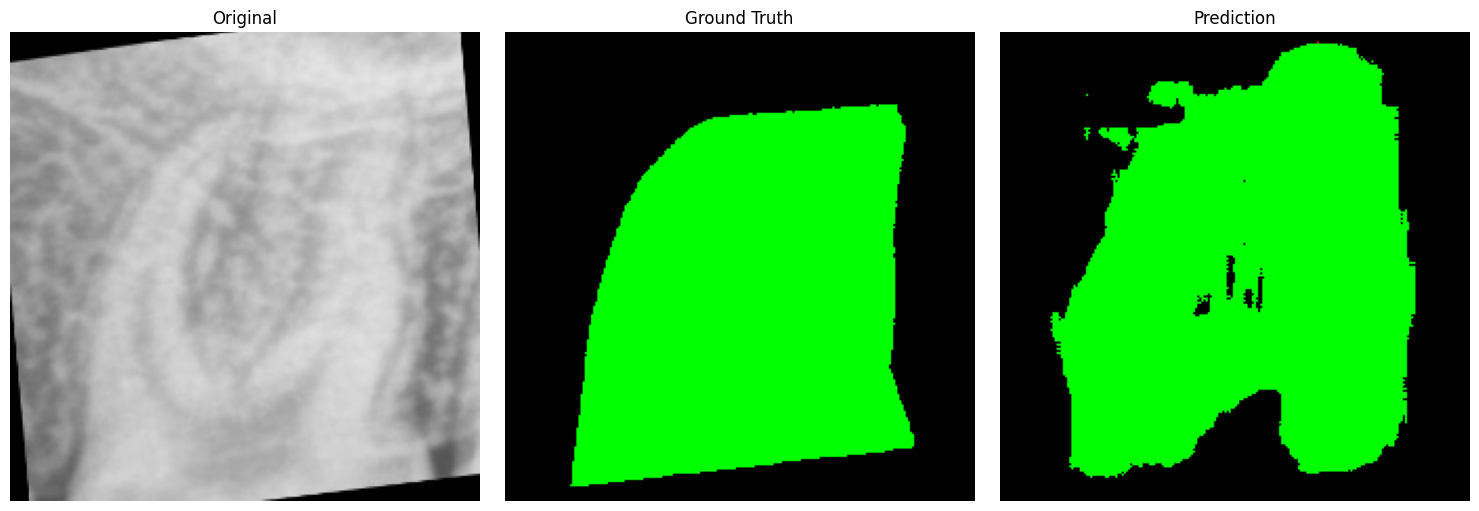

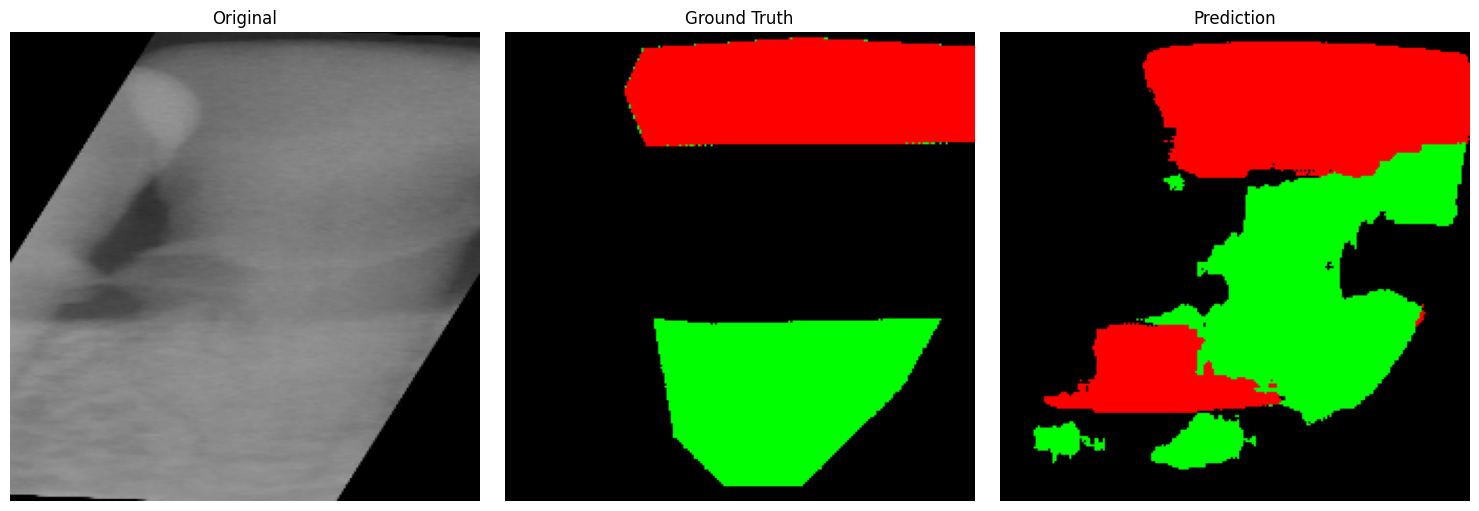

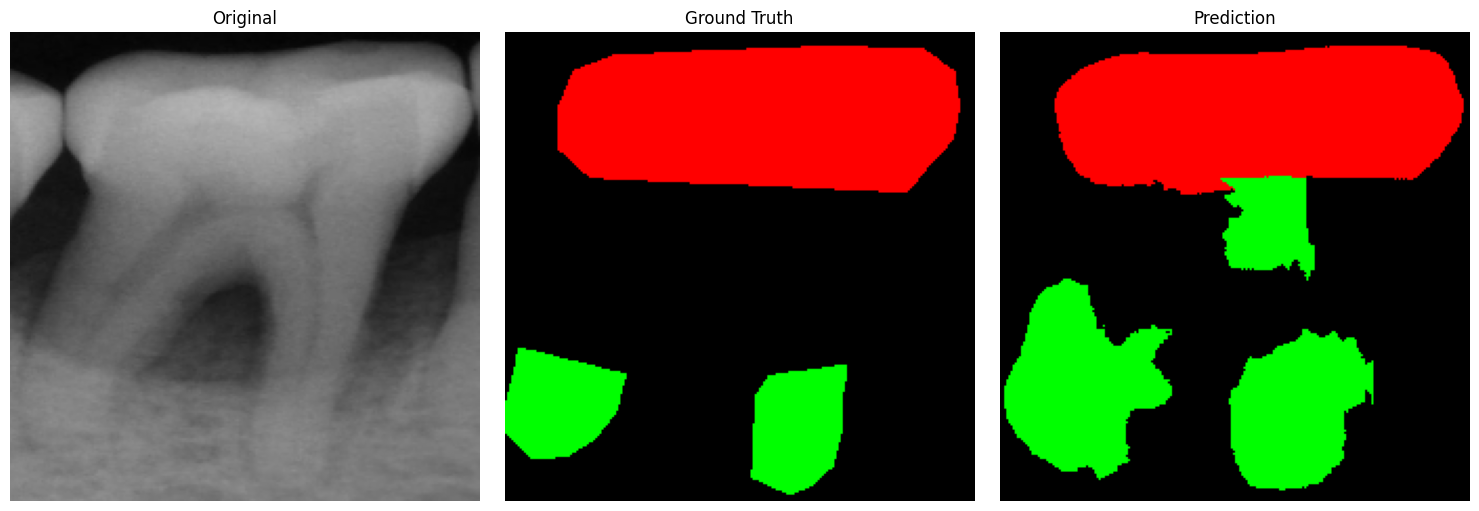

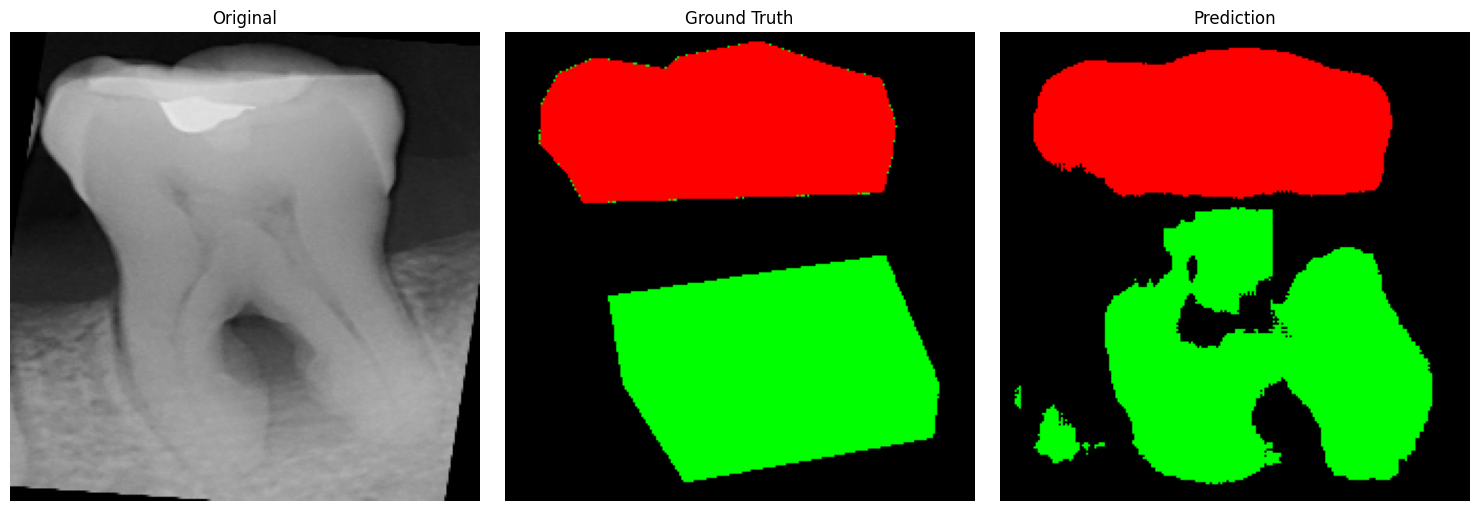

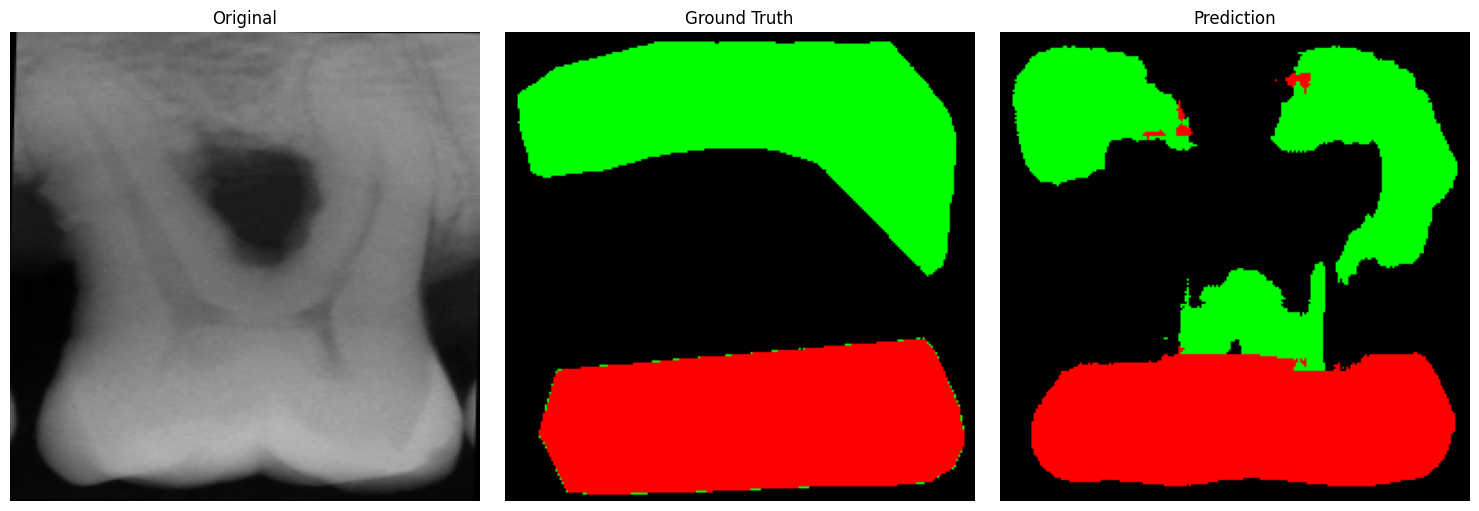

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.8490 - loss: 0.3660
Test Loss: 0.3955, Test Accuracy: 0.8374


In [85]:
#run training
base_dir = "../data/split_dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

if all(os.path.exists(p) for p in [train_dir, val_dir, test_dir]):
    model, history = train_model(train_dir, val_dir, test_dir)
else:
    print("Please check dataset paths or run the data splitting script.")


In [28]:
from tensorflow.keras.models import load_model

model = load_model("best_unet_model.keras")

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
import tensorflow as tf

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = y_true.flatten()
    y_pred_f = y_pred.flatten()
    intersection = (y_true_f * y_pred_f).sum()
    return (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

# Load test data using the existing function
X_test, y_test, _ = load_dataset(test_dir)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=-1).astype(np.uint8)
y_true_labels = np.argmax(y_test, axis=-1).astype(np.uint8)

# Flatten for metrics
y_true_flat = y_true_labels.flatten()
y_pred_flat = y_pred_labels.flatten()

# Calculate metrics (excluding background class 0)
mask = y_true_flat > 0
precision = precision_score(y_true_flat[mask], y_pred_flat[mask], average='macro', zero_division=0)
recall = recall_score(y_true_flat[mask], y_pred_flat[mask], average='macro', zero_division=0)
f1 = f1_score(y_true_flat[mask], y_pred_flat[mask], average='macro', zero_division=0)
iou = jaccard_score(y_true_flat[mask], y_pred_flat[mask], average='macro', zero_division=0)
dice = dice_coefficient(tf.one_hot(y_true_flat[mask], N_CLASSES).numpy(), tf.one_hot(y_pred_flat[mask], N_CLASSES).numpy())

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"IoU: {iou:.4f}")
print(f"Dice Coefficient: {dice:.4f}")

# Export model as TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('dental_segmentation_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("TFLite model exported as dental_segmentation_model.tflite")

NameError: name 'model' is not defined

5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step


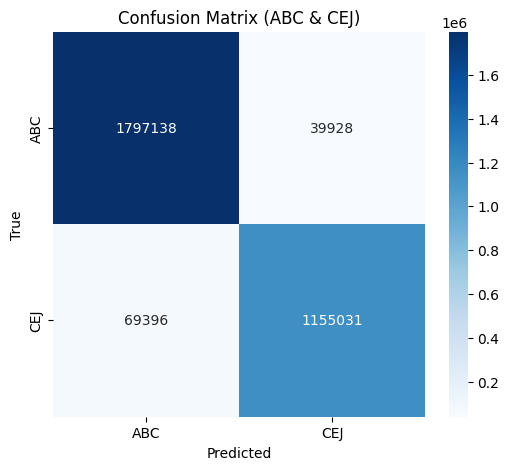

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Get predicted and true labels for each pixel
y_pred_labels = np.argmax(model.predict(X_test), axis=-1).flatten()
y_true_labels = np.argmax(y_test, axis=-1).flatten()

# Exclude background (class 0) if desired
mask = y_true_labels > 0
cm = confusion_matrix(y_true_labels[mask], y_pred_labels[mask], labels=[1, 2])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['ABC', 'CEJ'], yticklabels=['ABC', 'CEJ'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (ABC & CEJ)')
plt.show()